# Tarea 1 2026 — Modelos No Lineales

### Estudiante: Diego Álamos Valdivieso
### Carrera: Ingeniería Civil Matemática
### Asignatura: Data Analysis & Machine Learning
### Profesor: Juan Carlos Caro Seguel

# Pregunta 1

### Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

## Solución:

Primero que nada importamos la librerías necesarias para realizar un análisis de los datos, y seguidamente los inspeccionamos usando `.head()` y `.shape` (esta última para saber las dimensiones del dataset).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn
import scipy 
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("muted")

In [12]:
df = pd.read_csv('../../../data/student_productivity.csv')

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 5621 filas × 22 columnas


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


Ahora inspeccionamos toda la data para identificar los tipos de datos que tenemos (según la terminología de pandas).

- `int64` / `float64`: para variables numéricas continuas o discretas.
- `object` / `str`: para texto; pandas las usa por defecto para cadenas y categorías.

Asimismo, aprovechamos de analizar los datos `NaN` que puedan haber en cada columna.

In [13]:
print("=== Tipos de datos ===")
print(df.dtypes)

=== Tipos de datos ===
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   object 
 3   academic_level        4991 non-null   object 
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   object 
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   object 
 14  upcoming_deadline     4904 non-null   float64
 15  internet_quality     

In [15]:
df['exercise_minutes'].unique()

array(['54.0', '63.0', '28.0', '55.0', '60.0', '43.0', '52.0', '125.0',
       '26.0', '148.0', '16.0', '1.0', '102.0', '134.0', '122.0',
       '121.0 min', '10.0', '79.0', '65.0', nan, '30.0', '14.0',
       '22.0 min', '41.0', '133.0', '147.0', '62.0', '127.0', '89.0',
       '61.0', '10.0 min', '35.0', '6.0', '42.0', '124.0', '136.0',
       '31.0', '46.0', '84.0', '29.0', '80.0 min', '106.0', '4.0', '8.0',
       '71.0', '129.0', '96.0', '137.0', '123.0', '78.0', '108.0', '19.0',
       '11.0', '131.0', '111.0', '113.0', '74.0', '85.0', '39.0', '88.0',
       '42.0 min', '110.0', '83.0', '126.0', '98.0 min', '18.0', '92.0',
       '13.0', '17.0', '27.0', '67.0 min', '23.0', '76.0 min', '70.0 min',
       '95.0', '50.0', '119.0', '15.0', '91.0', '90.0 min', '5.0', '76.0',
       '32.0', '84.0 min', '101.0', '33.0', '114.0', '132.0', '118.0',
       '68.0', '25.0', '100.0', '107.0', '105.0 min', '81.0 min', '120.0',
       '105.0', '57.0', '88.0 min', '64.0', '90.0', '94.0', '66.0',

In [16]:
df['academic_level'].value_counts()

academic_level
Postgraduate      1395
Undergraduate     1380
High School       1368
High School        300
Postgraduate       300
Undergraduate      248
Name: count, dtype: int64

In [17]:
df['part_time_job'].value_counts()

part_time_job
No     1838
Yes    1753
yes     696
no      631
Name: count, dtype: int64

In [18]:
(df.isnull().sum() / len(df)) * 100

student_id               0.000000
age                     11.528198
gender                   9.927059
academic_level          11.207970
study_hours             10.211706
self_study_hours        11.866216
online_classes_hours    12.133072
social_media_hours      11.670521
gaming_hours            11.670521
sleep_hours              9.838107
screen_time_hours       10.425191
exercise_minutes        10.656467
caffeine_intake_mg      10.674257
part_time_job           12.506671
upcoming_deadline       12.755737
internet_quality         9.304394
mental_health_score     12.008539
drug_use                72.994129
focus_index             11.261341
burnout_level           12.737947
productivity_score      11.350294
exam_score              12.613414
dtype: float64

In [19]:
df['upcoming_deadline'].unique()

array([ 0.,  1., nan])

Con lo anterior nuestros principales hallazgos son los siguiente:

- **`drug_use`**: 73% de NaN. Esta variable casi no tiene información utilizable. La excluiremos de los modelos principales o la trataremos con mucho cuidado.
- **`exam_score`** (709 NaN): Los NaN aquí son distintos a los valores `1.0`. Los `1.0` sabemos que corresponden a alumnos que no rindieron el examen (por el enunciado). Los NaN en `exam_score` representan observaciones donde directamente no se registró la nota — los trataremos como dato faltante sin clasificar al construir nuestra variable binaria.
- El resto de variables tienen un porcentaje de de NaN manejables.
- **`exercise_minutes`** (Tipo object): Contiene una mezcla de formatos numéricos y de texto (ej. "30.0" y "30.0 min"). Al no ser estrictamente numérica, no se puede operar matemáticamente con ella. Limpiaremos el texto (eliminando donde aparezca "min") y la convertiremos a float.
- **`academic_level`** (Tipo str): Presenta "defectos" en forma de espacios en blanco extra al final de los textos (ej. "Undergraduate "). Habra que unificar según corresponda a las categorías artificiales con las reales.
- **`part_time_job`** (Tipo str): Tiene capitalización que provoca inconsistencia (ej. "no" vs "No"). Estandarizaremos el texto (por ejemplo, todo a minúsculas o todo a formato título) para obtener las frecuencias de la variable categórica correctamente.

Luego, realizamos la limpieza de las variables según los hallazgos anteriores:

In [20]:
# exercise_minutes: eliminamos ' min' y convertimos a numérico ──────────────
# Antes de la limpieza
print("Antes - muestra de exercise_minutes:", df['exercise_minutes'].dropna().unique()[:6])

df['exercise_minutes'] = (
    df['exercise_minutes']
    .astype(str)
    .str.replace(' min', '', regex=False)
    .str.strip()
)
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

print("Después - dtype:", df['exercise_minutes'].dtype)
print("Después - muestra:", df['exercise_minutes'].dropna().unique()[:6])

Antes - muestra de exercise_minutes: ['54.0' '63.0' '28.0' '55.0' '60.0' '43.0']
Después - dtype: float64
Después - muestra: [54. 63. 28. 55. 60. 43.]


In [21]:
# academic_level: eliminamos espacios al final
print("Antes:", df['academic_level'].value_counts(dropna=False).to_dict())

df['academic_level'] = df['academic_level'].str.strip()

print("Después:", df['academic_level'].value_counts(dropna=False).to_dict())

Antes: {'Postgraduate': 1395, 'Undergraduate': 1380, 'High School': 1368, nan: 630, 'High School ': 300, 'Postgraduate ': 300, 'Undergraduate ': 248}
Después: {'Postgraduate': 1695, 'High School': 1668, 'Undergraduate': 1628, nan: 630}


In [22]:
# part_time_job: tratamos a las letras mayúsculas y minúsculas
print("Antes:", df['part_time_job'].value_counts(dropna=False).to_dict())

df['part_time_job'] = df['part_time_job'].str.strip().str.capitalize()

print("Después:", df['part_time_job'].value_counts(dropna=False).to_dict())

Antes: {'No': 1838, 'Yes': 1753, nan: 703, 'yes': 696, 'no': 631}
Después: {'No': 2469, 'Yes': 2449, nan: 703}


In [23]:
# Hacemos una Verificación final 
print("=== Tipos de datos DESPUÉS de limpieza ===")
print(df.dtypes)

=== Tipos de datos DESPUÉS de limpieza ===
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes        float64
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


Continuando con nuestro análisis preliminar, ahora procedemos a realizar estadísticas decriptivas para poder caracterizar de mejor forma a las variables en juego que estimemos más importantes (conocer aspectos de la distribución de cada una). En este caso, lo haremos para aquellas que sean de tipo numérico. 

Las **estadísticas descriptivas** que determinaremos serán estas:
- **Media**: promedio
- **Mediana**: percentil 50.
- **Desviación estándar**: dispersión alrededor de la media.
- **Min/Max**: rango de los datos.
- **Asimetría (skewness)**: si > 0, la distribución tiene cola derecha larga; si < 0, cola izquierda.

In [24]:
desc = df.describe().T
desc['skewness'] = df.skew(numeric_only=True)
desc['missing_%'] = (df.isnull().sum() / len(df) * 100).round(1)
print(desc[['count','mean','std','min','50%','max','skewness','missing_%']].to_string())

                       count         mean          std   min       50%      max  skewness  missing_%
student_id            5621.0  2811.000000  1622.787263   1.0  2811.000  5621.00  0.000000        0.0
age                   4973.0    20.510557     2.876399  16.0    20.000    25.00 -0.006821       11.5
study_hours           5047.0     4.538708     1.819412   0.0     4.530    11.84  0.061115       10.2
self_study_hours      4954.0     2.480454     1.178094   0.0     2.480     7.41  0.088885       11.9
online_classes_hours  4939.0     2.012296     0.983104   0.0     2.010     6.00  0.125344       12.1
social_media_hours    4965.0     3.002872     1.472740   0.0     2.990     8.28  0.115377       11.7
gaming_hours          4965.0     1.571458     1.112557   0.0     1.500     5.64  0.428004       11.7
sleep_hours           5068.0     7.023301     1.159948   4.0     7.015    10.00  0.005888        9.8
screen_time_hours     5035.0     6.979045     2.482912   1.0     6.950    15.30  0.003769  

Algo que también nos puede ayudar a complementar la información de esta última tabla, es confeccionar un **histograma** para observar la frecuencia de los valores en intervalos. 

Asimismo, si las líneas de media y mediana coinciden, la distribución es casi simétrica; en caso contrario habrá asimetría debido a sesgos (positivo si la media > mediana y negativo si media < mediana). Esto, junto al índice de asimetría, nos dará señales sobre la conveniencia de transfomar la variable antes de modelar.

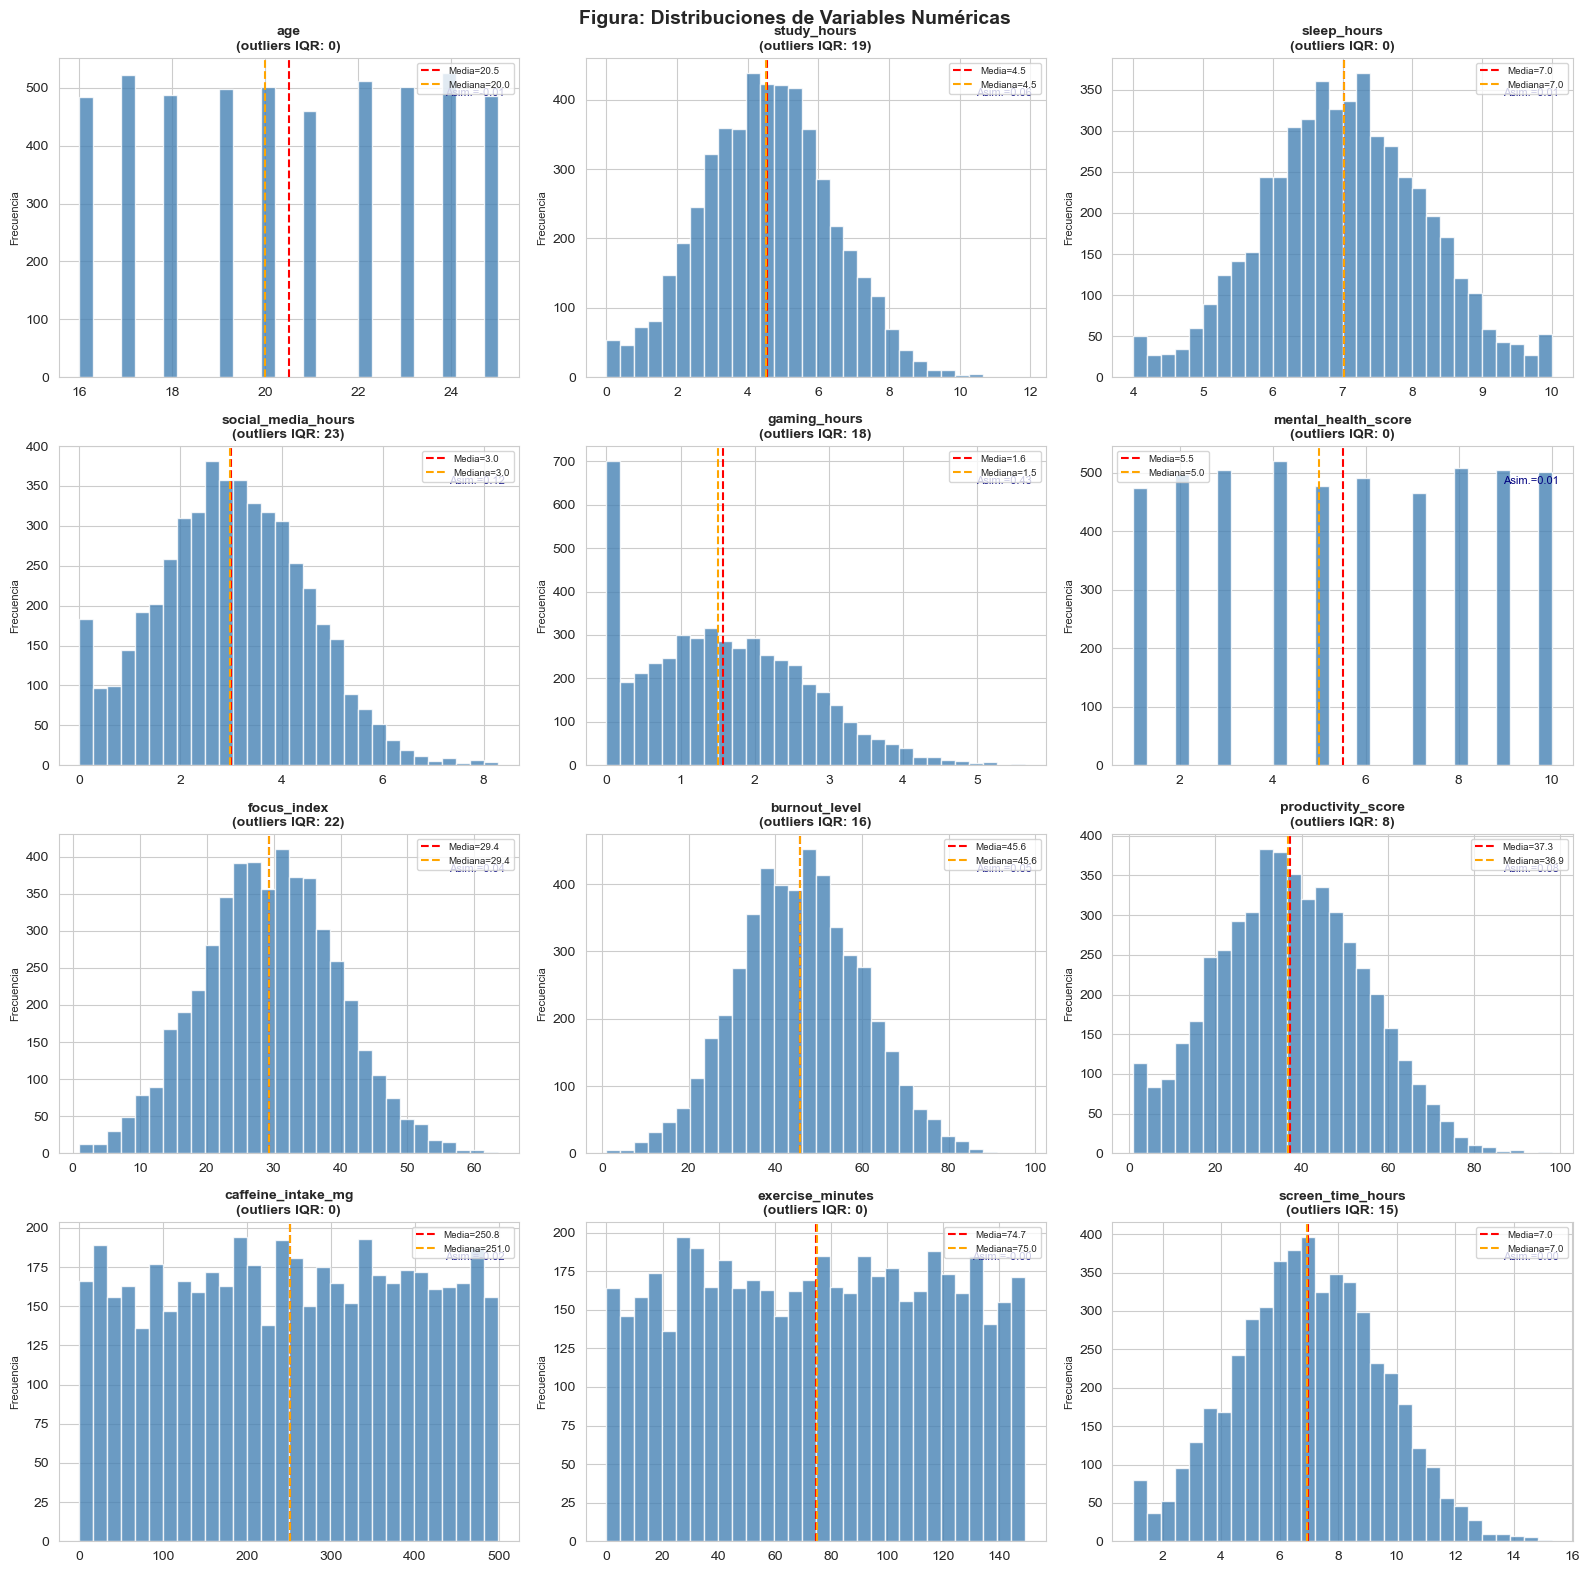

In [25]:
numeric_cols = ['age', 'study_hours', 'sleep_hours', 'social_media_hours',
                'gaming_hours', 'mental_health_score', 'focus_index',
                'burnout_level', 'productivity_score', 'caffeine_intake_mg',
                'exercise_minutes', 'screen_time_hours']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='red', linestyle='--', lw=1.5,
                    label=f'Media={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', lw=1.5,
                    label=f'Mediana={data.median():.1f}')
    axes[i].set_title(f'{col}\n(outliers IQR: {n_out})', fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].text(0.97, 0.88, f'Asim.={data.skew():.2f}', 
                 transform=axes[i].transAxes, ha='right', fontsize=8, color='navy')

plt.suptitle('Figura: Distribuciones de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

De esto último, podemos hacer las siguientes observaciones

- La mayoría de las variables continuas muestran distribuciones casi simétricas (asimetría cercana a cero), lo que es favorable para los modelos lineales.
- Los outliers son pocos y están dentro de rangos razonables (por ejemplo, `focus_index` con 22 casos extremos), por lo que no los eliminaremos (puede que sean casos reales).

Ahora procedemos a crear la variable binaria que nos pide el enunciado, la cual indicará quienes dieron o no el examen.

Sabemos que para la variable `exam_score` se tiene que 1.0 indica un estudiante que no rindió el examen. Por ende, seguiremos esa lógica para definir a la nueva variable `took_exam` (alumno rinde el examen):

- `exam_score == 1.0` → el estudiante **no rindió** → `took_exam = 0`
- `exam_score > 1.0`  → el estudiante **sí rindió** → `took_exam = 1`
- `exam_score == NaN` → **dato faltante genuino** → `took_exam = NaN` (para no introducir errores o sesgos)

In [26]:
# Inicializamos con NaN
df['took_exam'] = np.nan

# Hacemos las asignaciones según la regla definida arriba
df.loc[df['exam_score'] == 1.0, 'took_exam'] = 0   # No rindió
df.loc[df['exam_score'] > 1.0,  'took_exam'] = 1   # Sí rindió

# Verificamos
print("=== Distribución de took_exam ===")
v = df['took_exam'].value_counts(dropna=False)
total = len(df)
for val, count in v.items():
    label = {1.0: 'Sí rindió (1)', 0.0: 'No rindió (0)'}.get(val, 'Faltante (NaN)')
    print(f"  {label}: {count:,} ({count/total*100:.1f}%)")

=== Distribución de took_exam ===
  Sí rindió (1): 4,473 (79.6%)
  Faltante (NaN): 709 (12.6%)
  No rindió (0): 439 (7.8%)


Finalmente, vemos cómo queda nuestro nuevo dataset:

In [27]:
print("=== Estado final del dataset ===")
print(f"Dimensiones: {df.shape}")
print(f"\nInformación final de datos:")
df.info()

=== Estado final del dataset ===
Dimensiones: (5621, 23)

Información final de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   object 
 3   academic_level        4991 non-null   object 
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   float64
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null  

### Dataset final listo para modelar:
- **5,621 observaciones** × **23 variables** (22 originales + `took_exam`)
- **4,473 estudiantes** rindieron el examen (79.6% de los clasificables)
- **439 estudiantes** no rindieron el examen (7.8% del total)
- **709 valores faltantes** en `exam_score` tratados con transparencia

# Pregunta 2

### Ejecute un modelo de probabilidad lineal (MCO) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

El primer paso es seleccionar las variables independientes para construir nuestro modelo. Sin hacer ningún cálculo podemos descartar las siguientes:

- `exam_score`: esta define directamente a `took_exam` (la colinealidad perfecta supondría un problema)
- `student_id`: no es un contenido informativo (sólo sirve como identificador)
- `drug_use`: recordemos que tiene un 73% de NaN, lo cual constituye muy poca información útil
- `took_exam`: esta es la dependiente (la que queremos predecir)

Ahora bien, es necesario analizar la **multicolinealidad** que pueda existir entre las eventuales variables independientes/regresoras, puesto que si hay variables que midan "lo mismo", incluirlas podría "inflar" los errores estándar. Una buena herramienta para percatarnos de esto, es la **matriz de correlación**, la cual usamos a continuación para ver si efectivamente hay altas correlaciones entre variables potencialemente redundantes:

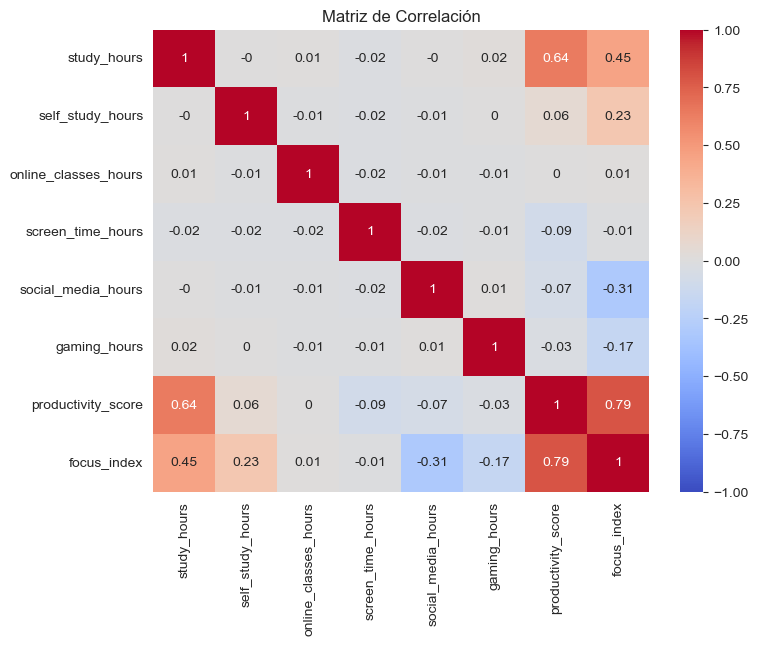

In [28]:
vars_check = ['study_hours', 'self_study_hours', 'online_classes_hours',
              'screen_time_hours', 'social_media_hours', 'gaming_hours',
              'productivity_score', 'focus_index']

corr_matrix = df[vars_check].corr().round(2)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

De lo anterior podemos decir que:

- Las variables `productivity_score` y `focus_index` presentan una alta correlación positiva (r = 0.79). No obstante, al medir cuestiones distintos, optamos por conservar ambas en el modelo lineal preliminar.
- Aunque la intuición decía lo contrario, `study_hours` no es la suma estricta de `self_study_hours` y `online_classes_hours`. Lo mismo aplica para `screen_time_hours` respecto a sus modalidades `self_study_hours`, `online_classes_hours` y `gaming_hours` (puede ver esto en df.head() en la pregunta 1).

No obstante a lo anterior, a fin de simplificar nuestro modelo, exluiremos a las variables agregadas `study_hours` y `screen_time_hours` en esta fase preliminar.

Lo que haremos a continuación será crear un modelo muy amplio con todas las variables no excluidas, identificar qué variables no son significativas (p-value > 0.05), y eliminarlas iterativamente para quedarnos con el modelo más parsimonioso que preserve el R².

In [29]:
formula_completa = """took_exam ~ self_study_hours + online_classes_hours +
                      social_media_hours + gaming_hours + sleep_hours +
                      age + exercise_minutes + caffeine_intake_mg +
                      mental_health_score + focus_index + burnout_level +
                      productivity_score + upcoming_deadline +
                      C(gender) + C(academic_level) + C(part_time_job) +
                      C(internet_quality)"""

modelo_completo = smf.ols(formula_completa, data=df).fit(cov_type='HC1')
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     29.11
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.37e-102
Time:                        14:01:51   Log-Likelihood:                -29.863
No. Observations:                3993   AIC:                             101.7
Df Residuals:                    3972   BIC:                             233.9
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

De la tabla de resultados anterior observamos que casi todas las variables que denotan un comportamiento extraprogramático (horas de sueño, redes sociales, videojuegos, cafeína, ejercicio, etc.) y de demografía (edad, género, trabajo part-time, calidad de internet) al ningún nivel de significancia convencional de 0.05

Las únicas variables que se podrían considerar significativas son:
- `focus_index` 
- `burnout_level`   
- `productivity_score` 
- `academic_level[Undergraduate]` 

Esto quiere decir que el hecho de que un estudiante que rinde el exame, no depende tanto de cuántas horas duerme o cuánto tiempo está en redes sociales, etc., sino que depende fundamentalmente de su estado psicológico y rendimiento académico global.

Teniendo todo esto en cuenta, procedemos a crear nuestro modelo final con las variables que, a nuestro criterio, son significativas:

In [30]:
formula_nueva = "took_exam ~ focus_index + burnout_level + productivity_score + C(academic_level)"

modelo_final = smf.ols(formula_nueva, data=df).fit(cov_type='HC1')
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     135.8
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          2.70e-134
Time:                        14:01:51   Log-Likelihood:                -92.624
No. Observations:                4442   AIC:                             197.2
Df Residuals:                    4436   BIC:                             235.6
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

Así, nuestro modelo final adquiere la siguiente estructura:

$$\hat{P}(\text{took\_exam} = 1) = 0.680 + 0.0035 \cdot \text{focus\_index} - 0.0025 \cdot \text{burnout\_level} + 0.0060 \cdot \text{productivity\_score} + 0.035 \cdot \mathbb{I}_{\text{Undergrad}} + 0.016 \cdot \mathbb{I}_{\text{Postgrad}}$$

Las interpretaciones de los coeficientes de las variables cuantitativas son:

- `focus_index` → cada punto adicional en el índice de concentración aumenta la probabilidad de rendir en **+0.35 puntos pocentuales** 
- `burnout_level` → cada punto adicional de agotamiento reduce la probabilidad de rendir en **−0.25 puntos porcentuales** 
- `productivity_score` → cada punto adicional de productividad aumenta la probabilidad en **+0.60 puntos porcentuales**

Ahora hacemos las interpretaciones para la variable categórica 'academic_level', teniendo presente que en este modelo usa a "High School" como la categoría base:

- `Undergraduate` → un estudiante de pregrado tiene una probabilidad de **3.55 puntos porcentuales mayor** de rendir el examen que uno de educación media
- `Postgraduate` → un estudiante de postgrado tiene una probabilidad de **1.57 puntos porcentuales mayor** de rendir el examen que uno de educación media

Por otro lado, mencionamos que el coeficiente de determinación para este modelo resulto ser **R² = 0.25**, es decir, el modelo explica el 25% de la variación de la variable dependiente (si el alumno rindió o no el examen). 

Asimismo, se tiene **N = 4442** observaciones (se pierden muchos registros por NaN en alguna(s) variable(s)).

# Pregunta 3

### Ejecute un modelo probit para responder a la pregunta 2. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

El primer paso es seleccionar a las variables que incluiremos en este nuevo modelo de tipo **probit** para predecir si un estudiante rinde o no el examen.

Ahora bien, a partir del desarrollo de la Pregunta 2, tenemos la ventaja de saber que nos conviene descartar a las variables `exam_score`, `student_id` y `drug_use`. Asimismo, también contamos con el estudio de la eventual multicolinealidad que podría darse entre ciertas variables, y esta no cambia entre modelos. 

De lo anterior, usamos las mismas variables no excluidas que usamos para construir el modelo completo de la Pregunta 2 para construir nuestro modelo probit amplio:

In [31]:
formula_completa = """took_exam ~ self_study_hours + online_classes_hours +
                       social_media_hours + gaming_hours + sleep_hours +
                       age + exercise_minutes + caffeine_intake_mg +
                       mental_health_score + focus_index + burnout_level +
                       productivity_score + upcoming_deadline +
                       C(gender) + C(academic_level) + C(part_time_job) +
                       C(internet_quality)"""

probit_completo = smf.probit(formula_completa, data=df).fit(cov_type='HC1', disp=False)
print(probit_completo.summary())

                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 3993
Model:                         Probit   Df Residuals:                     3972
Method:                           MLE   Df Model:                           20
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5931
Time:                        14:01:52   Log-Likelihood:                -477.94
converged:                       True   LL-Null:                       -1174.5
Covariance Type:                  HC1   LLR p-value:                3.409e-283
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.0910      0.685     -0.133      0.894      -1.434       1.252
C(gender)[T.Male]                     -0.1565      0.097   

Analizando la tabla, nuevamente notamos que las únicas variables significativas son:
- `focus_index` 
- `burnout_level`   
- `productivity_score` 
- `academic_level[Undergraduate]`

Esto refuerza el hallazgo de la Pregunta 2: rendir el examen está determinado primordialmente por el estado académico general y psicológico del estudiante.

Luego, creamos nuestro modelo probit final:

In [32]:
formula_final = "took_exam ~ focus_index + burnout_level + productivity_score + C(academic_level)"

modelo_probit = smf.probit(formula_final, data=df).fit(cov_type='HC1', disp=False)
print(modelo_probit.summary())

                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4442
Model:                         Probit   Df Residuals:                     4436
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5948
Time:                        14:01:52   Log-Likelihood:                -542.85
converged:                       True   LL-Null:                       -1339.8
Covariance Type:                  HC1   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.3800      0.200     -1.900      0.057      -0.772       0.012
C(academic_level)[T.Postgraduate]      0.2166      0.103   

No obstante, los coeficientes probit no son interpretables como probabilidades. Necesitamos determinar los efectos marginales promedio (AME) con `.get_margeff()` para así tener la magnitud del efecto en probabilidades (los coeficientes solo indican dirección y significancia).

In [33]:
efectos_marginales = modelo_probit.get_margeff()
print(efectos_marginales.summary())

       Probit Marginal Effects       
Dep. Variable:              took_exam
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
C(academic_level)[T.Postgraduate]      0.0146      0.007      2.117      0.034       0.001       0.028
C(academic_level)[T.Undergraduate]     0.0267      0.007      3.796      0.000       0.013       0.040
focus_index                            0.0032      0.001      6.295      0.000       0.002       0.004
burnout_level                         -0.0025      0.000    -11.356      0.000      -0.003      -0.002
productivity_score                     0.0070      0.000     21.968      0.000       0.006       0.008


Nuestro modelo probit final estimado es:

$$\hat{P}(\text{took\_exam} = 1) = \Phi\left( -0.380 + 0.047 \cdot \text{focus\_index} - 0.037 \cdot \text{burnout\_level} + 0.104 \cdot \text{productivity\_score} + 0.396 \cdot \mathbb{I}_{\text{Undergrad}} + 0.217 \cdot \mathbb{I}_{\text{Postgrad}} \right)$$

Las interpretaciones que podemos hacer para los coeficientes determinados son las siguientes (teniendo en cuenta que para la variable categórica `academic_leve`, la categoría base es "High School"):
- `focus_index` → **+0.0032** → un punto más de concentración implica que la probabilidad de rendir el examen sube 0.32 puntos porcentuales 
- `burnout_level` → **−0.0025** → un punto más de agotamiento implica que la probabilidad de rendir el examen baja 0.25 puntos porcentuales
- `productivity_score` → **+0.0070** → un punto más de productividad implica que la probabilidad de rendir el examen sube 0.7 puntos porcentuales 
- `Undergraduate` → **+0.027** → un estudiante de pregrado tiene una probabilidad de 2.7 puntos porcentuales más de rendir el examen que uno de educación media
- `Postgraduate` → **+0.015** → un estudiante de postgrado tiene una probabilidad de 1.5 puntos porcentuales más de rendir el examen que uno de educación media (a diferencia de "Undergraduate", es menos preciso estadísticamente).

**Observación:** los AME del Probit son muy similares a los coeficientes del MCO (por ejemplo, 0.35 pp vs 0.32 pp para `focus_index`; 0.60 pp vs 0.70 pp para `productivity_score` respectivamente)

Según la teoría, para los modelos MLE (Estimación de Máxima Verosimilitud), tal es el caso para probit (y logit), no existe un R² estándar como en MCO. Sin embargo, el **Pseudo-R² de McFadden** es el análogo más usado, por ende, lo calculamos:

In [34]:
ll_full = modelo_probit.llf
ll_nulo = modelo_probit.llnull
mcfadden = 1 - ll_full / ll_nulo

print(f"Probit Pseudo-R² de McFadden: {mcfadden:.4f}")

Probit Pseudo-R² de McFadden: 0.5948


Luego, se tiene que **R²-McFadden ≈ 0.59**, lo que es alto. Es importante decir que esto no significa que el modelo explica el 59% de la varianza de la variable dependiente (esa interpretación solo aplica al R² de MCO).

Asimismo, se tiene **N = 4442** observaciones (al igual que en la Pregunta 2).

# Pregunta 4

### Ejecute un modelo logit para responder a la pregunta 2. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

El primer paso es seleccionar a las variables que incluiremos en este nuevo modelo de tipo **logit** para predecir si un estudiante rinde o no el examen.

A partir del desarrollo de la Pregunta 2 y la Pregunta 3, recordamos que nos conviene descartar a las variables `exam_score`, `student_id` y `drug_use`. Además, también contamos con el estudio de las posibles multicolinealidades que podrían darse entre ciertas variables, y este sigue siendo invariante entre modelos. 

A raíz de lo dicho, usamos las mismas variables no excluidas (las que usamos para construir los modelos completos de las Pregunta 2 y 3) para construir nuestro modelo logit amplio:

In [35]:
formula_completa = """took_exam ~ self_study_hours + online_classes_hours +
                       social_media_hours + gaming_hours + sleep_hours +
                       age + exercise_minutes + caffeine_intake_mg +
                       mental_health_score + focus_index + burnout_level +
                       productivity_score + upcoming_deadline +
                       C(gender) + C(academic_level) + C(part_time_job) +
                       C(internet_quality)"""

logit_completo = smf.logit(formula_completa, data=df).fit(cov_type='HC1', disp=False)
print(logit_completo.summary())

                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 3993
Model:                          Logit   Df Residuals:                     3972
Method:                           MLE   Df Model:                           20
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5920
Time:                        14:01:52   Log-Likelihood:                -479.16
converged:                       True   LL-Null:                       -1174.5
Covariance Type:                  HC1   LLR p-value:                1.146e-282
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.4716      1.274     -0.370      0.711      -2.969       2.026
C(gender)[T.Male]                     -0.2733      0.182   

Las únicas variables significativas en el modelo logit completo son las mismas que en las Preguntas 2 y 3: 
- `focus_index`
- `burnout_level`
- `productivity_score`
- `academic_level[Undergraduate]`

Sin embargo, esta vez ocurre que la variable `upcoming_deadline` tiene un p-valor inferior al umbral del 5% (p ≈ 0.043), pero dado que no aparece como significativa en los modelos anteriores (MPL y Probit), por parsimonia y para poder comparar a los tres modelos en la Pregunta 5, la excluimos.

Construimos nuestro modelo logit final:

In [36]:
formula_final = "took_exam ~ focus_index + burnout_level + productivity_score + C(academic_level)"

modelo_logit = smf.logit(formula_final, data=df).fit(cov_type='HC1', disp=False)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4442
Model:                          Logit   Df Residuals:                     4436
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5931
Time:                        14:01:52   Log-Likelihood:                -545.15
converged:                       True   LL-Null:                       -1339.8
Covariance Type:                  HC1   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.7513      0.374     -2.010      0.044      -1.484      -0.019
C(academic_level)[T.Postgraduate]      0.3980      0.191   

Al igual que en el caso probit, los coeficientes hallados en el logit no pueden ser interpretados como cambios en probabilidades. Para ende, para obtener magnitudes en probabilidades, necesitamos nuevamente los efectos marginales promedio (AME):

In [37]:
efectos_logit = modelo_logit.get_margeff()
print(efectos_logit.summary())

        Logit Marginal Effects       
Dep. Variable:              took_exam
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
C(academic_level)[T.Postgraduate]      0.0146      0.007      2.087      0.037       0.001       0.028
C(academic_level)[T.Undergraduate]     0.0259      0.007      3.648      0.000       0.012       0.040
focus_index                            0.0032      0.001      6.359      0.000       0.002       0.004
burnout_level                         -0.0024      0.000    -10.879      0.000      -0.003      -0.002
productivity_score                     0.0070      0.000     22.208      0.000       0.006       0.008


Nuestro modelo logit final estimado es:

$$\hat{P}(\text{took\_exam} = 1) = \Lambda\left( -0.751 + 0.087 \cdot \text{focus\_index} - 0.066 \cdot \text{burnout\_level} + 0.191 \cdot \text{productivity\_score} + 0.703 \cdot \mathbb{I}_{\text{Undergrad}} + 0.398 \cdot \mathbb{I}_{\text{Postgrad}} \right)$$

Las interpretaciones que podemos hacer para estos coeficientes determinados son las siguientes (recordando que para la variable categórica `academic_leve`, la categoría base es "High School"):
- `focus_index` → **+0.0032** → un punto más de concentración implica que la probabilidad de rendir el examen sube 0.32 puntos porcentuales 
- `burnout_level` → **−0.0024** → un punto más de agotamiento implica que la probabilidad de rendir el examen baja 0.24 puntos porcentuales
- `productivity_score` → **+0.0070** → un punto más de productividad implica que la probabilidad de rendir el examen sube 0.7 puntos porcentuales 
- `Undergraduate` → **+0.026** → un estudiante de pregrado tiene una probabilidad de 2.7 puntos porcentuales más de rendir el examen que uno de educación media
- `Postgraduate` → **+0.015** → un estudiante de postgrado tiene una probabilidad de 1.5 puntos porcentuales más de rendir el examen que uno de educación media (a diferencia de "Undergraduate", es menos preciso estadísticamente)

Finalmente, puesto que para logit no existe un R² estándar como en MCO, determinamos el **Pseudo-R² de McFadden**:

In [38]:
ll_full  = modelo_logit.llf
ll_nulo  = modelo_logit.llnull
mcfadden = 1 - ll_full / ll_nulo

print(f"Logit Pseudo-R² de McFadden = {mcfadden:.4f}")

Logit Pseudo-R² de McFadden = 0.5931


Así, se tiene que **R²-McFadden ≈ 0.59**, lo que es alto (es prácticamente idéntico al del Probit). Recordemos que esto no significa que el modelo explica el 59% de la varianza de la variable dependiente. 

Asimismo, se tiene **N = 4442** observaciones (al igual que en las Preguntas 2 y 3).

# Pregunta 5

### Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

## Solución:

La diferecia más notoria radica en cómo se interpretan los coeficientes. Mientras que los de MCO se pueden interpretar directamente como cambios en puntos porcentuales, los de Probit y Logit requieren ser transformados mediante cambios marginales para poder ser interpretados de la misma forma. Asimismo, Probit y Logit están diseñados para que su rango sea entre 0 y 1 (cosa que no necesariamente ocurre con un modelo MCO).

Acerca del modelo ideal para la investigación, el MCO se descarta por sus predicciones que puenden escapar de \[0,1\]. Por ende, tanto los modelos Probit como Logit pueden ser empleados para este estudio, ya que ambos presentan un ajuste decente (prácticamente similar) y son conocidos por usarse para predecir variables dicotómicas (tal como ocurre acá con la variable `took_exam`).

En cuanto a las variables que fueron robustas, fueron las usadas en los modelos finales de MCO, Probit y Logit:
- `productivity_score`
- `focus_index`
- `burnout_level`
- `academic_level[Undergraduate]`
  
Estas cuatro variables son plenamente robustas: significativas al 5% y preservan sus signos respectivamente.

# Pregunta 6

### Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

En este caso, no usaremos a la misma muestra de estudiantes, sino a aquellos que efectivamente rindieron el examen (`took_exam == 1`). 

Ahora bien, el modelo Poisson está diseñado para trabajar con cantidades discretas (numeros enteros positivos junto al cero). Como `exam_score` es una variable continua (números con decimales), será necesario realizar un ajuste para solventar este detalle: redondear al entero más cercano. Así creamos un nuevo dataset para este problema en particular:

In [39]:
exam = df[df['took_exam'] == 1].copy()

exam['exam_score_int'] = exam['exam_score'].round(0).astype(int)

exam.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score,took_exam,exam_score_int
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08,1.0,25
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83,1.0,38
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66,1.0,19
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78,1.0,8
5,6,19.0,Female,NaN,6.00,2.66,1.14,3.38,0.99,6.75,...,0.0,Poor,4.0,NaN,23.53,37.93,42.40,12.74,1.0,13


El segundo paso es llevar a cabo la selección de las variables independientes. Al igual a como ya hemos hecho antes, la estrategia general será crear un modelo completo (con muchas variables independientes) y luego lo "podaremos" para quedarnos con las variables que sean significativas, según el criterio del p-valor, y así obtener nuestro modelo final.

De lo que ya sabemos de las Preguntas 2, 3 y 4, sabemos que nos conviene descartar `student_id` y `drug_use`. Descartamos a la variable `took_exam` pues estamos enfocados solamente en quienes riendieron el examen (no nos importan quienes no lo rindieron), y también descartamos a la variable `exam_score` pues estamos enfocados en predecir a la variable `exam_score_int`. Asimismo, ya tenemos el estudio de las eventuales multicolinealidades que podrían darse entre ciertas variables (hecho en la Pregunta 2), y este no cambia entre modelos.

Construimos nuestro modelo Poisson completo:

In [40]:
formula_completa = """exam_score_int ~ self_study_hours + online_classes_hours +
                       social_media_hours + gaming_hours + sleep_hours +
                       age + exercise_minutes + caffeine_intake_mg +
                       mental_health_score + focus_index + burnout_level +
                       productivity_score + upcoming_deadline +
                       C(gender) + C(academic_level) + C(part_time_job) +
                       C(internet_quality)"""

poisson_completo = smf.poisson(formula_completa, data=exam).fit(cov_type='HC1', disp=False)
print(poisson_completo.summary())

                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 3648
Model:                        Poisson   Df Residuals:                     3627
Method:                           MLE   Df Model:                           20
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4315
Time:                        14:01:53   Log-Likelihood:                -11687.
converged:                       True   LL-Null:                       -20559.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              2.0764      0.069     30.029      0.000       1.941       2.212
C(gender)[T.Male]                     -0.0081      0.010   

De los resultados obtenidos para este modelo, notamos que las únicas variables significativas al 5% son las siguientes: 

- `focus_index`
- `burnout_level`
- `productivity_score`
- `mental_health_score`

Así, construimos nuestro modelo Poisson final (con esta cuatro variables):

In [41]:
formula_final = "exam_score_int ~ focus_index + burnout_level + productivity_score + mental_health_score"

modelo_poisson = smf.poisson(formula_final, data=exam).fit(cov_type='HC1', disp=False)
print(modelo_poisson.summary())

                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4030
Model:                        Poisson   Df Residuals:                     4025
Method:                           MLE   Df Model:                            4
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4316
Time:                        14:01:53   Log-Likelihood:                -12923.
converged:                       True   LL-Null:                       -22734.
Covariance Type:                  HC1   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.0199      0.024     85.687      0.000       1.974       2.066
focus_index             0.0130      0.001     18.060      0.000       0.012       0.014
burnout_level   

Al igual que en probit y logit, los coeficientes determinados para un modelo Poisson no son directamente interpretables como cambios en el valor esperado. Para poder interpretarlos de manera más natural hay que exponenciarlos para obtener la **Razón de Tasas de Incidencia(IRR)** de cada coeficiente:

In [42]:
params   = modelo_poisson.params
p_vals   = modelo_poisson.pvalues

irr_df = pd.DataFrame({
    'Coef. (log)':   params.round(4),
    'IRR':           np.exp(params).round(4)
})
print(irr_df.to_string())

                     Coef. (log)     IRR
Intercept                 2.0199  7.5377
focus_index               0.0130  1.0130
burnout_level            -0.0089  0.9911
productivity_score        0.0213  1.0215
mental_health_score       0.0071  1.0072


Así, el modelo Poisson final, el cual determina el valor esperado de la variable `exam_score_int`, es:

$$E[\text{exam\_score\_int} \mid X] = e^{\,2.020 \;+\; 0.013 \cdot \text{focus\_index} \;-\; 0.009 \cdot \text{burnout\_level} \;+\; 0.021 \cdot \text{productivity\_level} \;+\; 0.007 \cdot \text{mental\_health\_score}}$$

Las interpretaciones que podemos hacer para estos coeficientes determinados son las siguientes:
- `focus_index` → **1.013** → cuando la concentración aumenta en 1 unidad, la nota aumenta un 1.3%
- `burnout_level` → **0.991** → cuando la el agotamiento aumenta en 1 unidad, la nota disminuye un 0.89% 
- `productivity_score` → **1.022** → cuando la concentración aumenta en 1 unidad, la nota aumenta un 2.15%
- `mental_health_score` → **1.007** → cuando la salud mental aumenta en 1 unidad, la nota aumenta un 0.72%

Por último, para modelos Poisson, ni el R² de MCO ni el Pseudo-R² de McFadden son apropiados para evaluar el ajuste. Para modelos de conteo las métricas apropiadas para comparar modelos de conteo son: el **AIC** y el  **BIC**, los cuales penalizan la complejidad del modelo (mientras menores es mejor); y la **Correlación** entre $\hat{y}$ (valores predichos) e $y$ (valores reales), la cual mide la capacidad predictiva directamente.

In [43]:
print(f"AIC : {modelo_poisson.aic:.2f}")
print(f"BIC : {modelo_poisson.bic:.2f}")

y_hat = modelo_poisson.predict(exam.dropna(subset=['focus_index','burnout_level',
                                                     'productivity_score','mental_health_score',
                                                     'exam_score_int']))
y_real = exam.dropna(subset=['focus_index','burnout_level',
                              'productivity_score','mental_health_score',
                              'exam_score_int'])['exam_score_int']
corr = np.corrcoef(y_hat, y_real)[0,1]
print(f"\nCorrelación predicho vs. real: r = {corr:.4f}")

AIC : 25856.04
BIC : 25887.55

Correlación predicho vs. real: r = 0.8715


Así, se tiene que **AIC ≈ 25856**, **BIC ≈ 25887** y **r ≈ 0.87**.

Además, se tiene **N = 4030** observaciones.

# Pregunta 7

### Determine si existe sobre dispersión en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

## Solución:

Si bien hay más de una forma para determinar la sobredispersión, nosotros nos limitaremos a usar un test simple, mencionado en cátedra, que usa los resultados del modelo Poisson y es quizá el indicador más directo de sobredispersión en un modelo ajustado:

$$\hat{\phi} = \frac{\chi^2_{\text{Pearson}}}{n - k} = \frac{\sum_i (y_i - \hat{\lambda}_i)^2 / \hat{\lambda}_i}{n - k}$$

donde $n$ es el tamaño de muestra y $k$ el número de parámetros. Bajo Poisson correcto, este ratio debería ser $\approx 1.0$; si $\hat{\phi}$ es mayor que 1, indica sobredispersión:

In [44]:
df_res = exam[['exam_score_int','focus_index','burnout_level',
               'productivity_score','mental_health_score']].dropna().copy()
df_res['lambda_hat'] = modelo_poisson.predict(df_res)

pearson_chi2 = np.sum((df_res['exam_score_int'] - df_res['lambda_hat'])**2 / df_res['lambda_hat'])
df_residual = len(df_res) - len(modelo_poisson.params)
phi_hat = pearson_chi2 / df_residual

print(f"Pearson chi² = {pearson_chi2:.2f}")
print(f"df residual = {df_residual}  (n={len(df_res)}, k={len(modelo_poisson.params)})")
print(f"Ratio phi = Pearson chi²/df = {phi_hat:.4f}")
print()
if phi_hat > 1.0:
    print("Hay Sobredispersión")
else:
    print("No hay evidencia de sobredispersión")

Pearson chi² = 6467.29
df residual = 4025  (n=4030, k=5)
Ratio phi = Pearson chi²/df = 1.6068

Hay Sobredispersión


Habiendo confirmado la sobredispersión, ahora necesitamos estimar el parámetro $\alpha$ del modelo Binomial Negativa. Usaremos el método visto en clases, el cual requiere de una regresión auxiliar (Cameron & Trivedi):

**Paso 1:** Construimos la variable auxiliar:
$$aux_i = \frac{(y_i - \hat{\lambda}_i)^2 - y_i}{\hat{\lambda}_i}$$

**Paso 2:** Hacemos una regresión de $aux_i$ sobre $\hat{\lambda}_i$ sin constante:
$$aux_i = \alpha \cdot \hat{\lambda}_i + \varepsilon_i$$

**Paso 3:** El coeficiente $\hat{\alpha}$ de esta regresión es la estimación de $\alpha$.

In [45]:
df_res['aux'] = ((df_res['exam_score_int'] - df_res['lambda_hat'])**2 - df_res['exam_score_int']) / df_res['lambda_hat']

modelo_aux = sm.OLS(df_res['aux'], df_res['lambda_hat']).fit()

print(modelo_aux.summary())

                                 OLS Regression Results                                
Dep. Variable:                    aux   R-squared (uncentered):                   0.043
Model:                            OLS   Adj. R-squared (uncentered):              0.042
Method:                 Least Squares   F-statistic:                              179.4
Date:                Wed, 22 Apr 2026   Prob (F-statistic):                    4.66e-40
Time:                        14:01:53   Log-Likelihood:                         -8983.2
No. Observations:                4030   AIC:                                  1.797e+04
Df Residuals:                    4029   BIC:                                  1.797e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Luego, tenemos que el alfa óptimo estimado es  $\hat{\alpha} \approx 0.0204$ (lo usaremos como punto de referencia para el modelo Binomial Negativa de la siguiente pregunta.

# Pregunta 8

### Usando la información anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

Primero que nada, hacemos la selección de las variables independientes. De igual forma a como ya hemos hecho antes, la estrategia es crear un modelo completo (con muchas variables independientes) y luego lo "podaremos" para quedarnos con las variables que sean significativas, según el criterio del p-valor.

Sabemos que nos conviene descartar `student_id` y `drug_use`. Como hicimos en la Pregunta 6, descartamos a la variable `took_exam` pues estamos enfocados solamente en quienes riendieron el examen (no nos importan quienes no lo rindieron), y también descartamos a la variable `exam_score` pues estamos enfocados en predecir a la variable `exam_score_int`. Asimismo, ya tenemos el estudio de las eventuales multicolinealidades que podrían darse entre ciertas variables (hecho en la Pregunta 2), y este es independiente de los modelos.

Construimos nuestro modelo NB completo:

In [46]:
formula_completa = """exam_score_int ~ self_study_hours + online_classes_hours +
                       social_media_hours + gaming_hours + sleep_hours +
                       age + exercise_minutes + caffeine_intake_mg +
                       mental_health_score + focus_index + burnout_level +
                       productivity_score + upcoming_deadline +
                       C(gender) + C(academic_level) + C(part_time_job) +
                       C(internet_quality)"""

modelo_nb_completo = smf.negativebinomial(formula_completa, data=exam).fit(disp=False)
print(modelo_nb_completo.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 3648
Model:               NegativeBinomial   Df Residuals:                     3627
Method:                           MLE   Df Model:                           20
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                -0.03236
Time:                        14:01:53   Log-Likelihood:                -14394.
converged:                      False   LL-Null:                       -13942.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              2.0764        nan        nan        nan         nan         nan
C(gender)[T.Male]                     -0.0081        nan   

Dado que surge el inconveniente de que todos los p-valores son 'nan' (lo cual puede indicar una sobreparametrización), procedemos a usar las mismas variables con las que construimos nuestro modelo Poisson final. Así, nuestro modelo NB final es el siguiente:

In [47]:
formula_final = "exam_score_int ~ focus_index + burnout_level + productivity_score + mental_health_score"

modelo_nb = smf.negativebinomial(formula_final, data=exam).fit(disp=False)
print(modelo_nb.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 4030
Model:               NegativeBinomial   Df Residuals:                     4025
Method:                           MLE   Df Model:                            4
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1748
Time:                        14:01:54   Log-Likelihood:                -12716.
converged:                       True   LL-Null:                       -15410.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.9675      0.023     86.414      0.000       1.923       2.012
focus_index             0.0141      0.001     18.586      0.000       0.013       0.016
burnout_level   

Notamos que todas las variables permanecen significativas al nivel de 5%. Además, se tiene el parámetro `alpha`, el cual es $\hat{\alpha}$ estimado directamente por MLE, que es el valor más preciso disponible (el que obtuvimos en la Pregunta 7 era una referencia o punto de partida). 

| Fuente | $\hat{\alpha}$ |
|---|---|
| Regresión auxiliar (P7) | 0.0204 |
| MLE directo NB (este modelo) | **≈ 0.0283** |

Ahora, para poder interpretar a los coeficientes hallados, tenemos que exponenciarlos para obtener la **Razón de Tasas de Incidencia(IRR)** de cada uno, igual a como hicimos en la Pregunta 6 para el modelo Poisson final:

In [48]:
params_nb   = modelo_nb.params.drop('alpha')
p_vals_nb   = modelo_nb.pvalues.drop('alpha')

irr_df_nb = pd.DataFrame({
    'Coef. (log)':  params.round(4),
    'IRR':          np.exp(params).round(4)
})
print(irr_df_nb.to_string())

                     Coef. (log)     IRR
Intercept                 2.0199  7.5377
focus_index               0.0130  1.0130
burnout_level            -0.0089  0.9911
productivity_score        0.0213  1.0215
mental_health_score       0.0071  1.0072


Así, el modelo NB final, el cual determina el valor esperado de la variable `exam_score_int`, es:

$$E[\text{exam\_score\_int} \mid X] = e^{\,1.968 \;+\; 0.014 \cdot \text{focus\_index} \;-\; 0.010 \cdot \text{burnout\_level} \;+\; 0.023 \cdot \text{productivity\_score} \;+\; 0.006 \cdot \text{mental\_health\_score}}$$

Las interpretaciones son las siguientes:
- `focus_index` → **1.014** → cuando la concentración aumenta en 1 unidad, la nota aumenta un 1.42% 
- `burnout_level` → **0.990** → cuando la el agotamiento aumenta en 1 unidad, la nota disminuye un 0.96% 
- `productivity_score` → **1.023** → cuando la concentración aumenta en 1 unidad, la nota aumenta un 2.28% 
- `mental_health_score` → **1.006** → cuando la salud mental aumenta en 1 unidad, la nota aumenta un 0.57%

Como se puede apreciar, la interpretación es idéntica en forma a la del Poisson. La diferencia está en que los intervalos de confianza serán más amplios para reflejar correctamente la sobredispersión real de los datos.

Finalmente determinamos algunas métricas (las mismas que para el modelo Poisson final de la Pregunta 6) para poder comparar nuestro modelo:

In [49]:
print(f"AIC : {modelo_nb.aic:.2f}")
print(f"BIC : {modelo_nb.bic:.2f}")

y_hat_nb = modelo_nb.predict(exam.dropna(subset=['focus_index','burnout_level',
                                                     'productivity_score','mental_health_score',
                                                     'exam_score_int']))
y_real = exam.dropna(subset=['focus_index','burnout_level',
                              'productivity_score','mental_health_score',
                              'exam_score_int'])['exam_score_int']
corr = np.corrcoef(y_hat_nb, y_real)[0,1]
print(f"\nCorrelación predicho vs. real: r = {corr:.4f}")

AIC : 25444.14
BIC : 25481.95

Correlación predicho vs. real: r = 0.8660


Así, se tiene que **AIC ≈ 25444**, **BIC ≈ 25481** y **r ≈ 0.87**.

Además, se tiene **N = 4030** observaciones.

# Pregunta 9

### Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investigación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

## Solución:

En cuanto a las diferencias, notamos que no son muy abundantes en lo que respecta a los coeficientes estimados y sus respectivos IRR (de hecho son bastante similares y preservan el sentido de las interpretaciones), sin embargo la diferencia principal radica en como cada modelo trata la incertidumbre. Mientras que el modelo Poisson asume que la media y la varianza son iguales ($Var[Y] = \mu$) y los datos que usamos para construir el modelo presentan sobredispersión, El modelo Binomial Negativo soluciona esta sobredispersión introduciendo el parámetro $\alpha$, permitiendo que el modelo proyecte una varianza mucho más ajustada a la realidad.

Es por ello que el modelo más idóneo para responder a la pregunta de investigación sería el modelo final de Binomial Negativa, esto debido a que en la Pregunta 7 nos percatamos de que existe sobredispesión, y este modelo permite explicar mejor la heterogeneidad no observada entre estudiantes (por ejemplo, el contexto familiar y la suerte en el día del examen pueden generar variabilidad extra en las notas que el modelo de Poisson no puede absorber). El parámetro $\hat\alpha \approx 0.028$ cuantifica exactamente esa dispersión extra, obteniendo un modelo más confiable.

En cuanto a las variables que fueron robustas, fueron las usadas en los modelos finales de Poisson y Binomial Negativa, i.e.:
- `productivity_score`
- `focus_index`
- `burnout_level`
- `mental_health_score`
  
Estas cuatro variables son plenamente robustas: significativas al 5% (incluso al 1% ) en Poisson y en NB, con el mismo signo e IRR prácticamente idénticos en ambos. Se puede decir que los factores psicológicos y de rendimiento son más dominates que los hábitos de vida diaria para explicar quién rinde el examen y para explicar qué nota se obtiene.
